<a href="https://colab.research.google.com/github/kasugy/CheckPoint/blob/main/An%C3%A1lisis%20de%20caso%3A%20Fundamentos%20del%20aprendizaje%20de%20m%C3%A1quina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

METRICAS DE EVALUACION PARA LOS TRES CASOS

CASO A: Prediccion de ventas semanales (Regresion)
Modelo: Random Forest Regressor

Resultados del modelo:
RMSE (Root Mean Square Error): 22.43 miles de unidades
MAE (Mean Absolute Error): 18.58 miles de unidades
R² (Coeficiente de determinacion): 0.8550
MAPE (Mean Absolute Percentage Error): 8.25%

Interpretacion:
- El error tipico es de 22.43 miles de unidades monetarias
- El modelo explica el 85.5% de la variabilidad de las ventas
- Las predicciones fallan en promedio un 8.3%


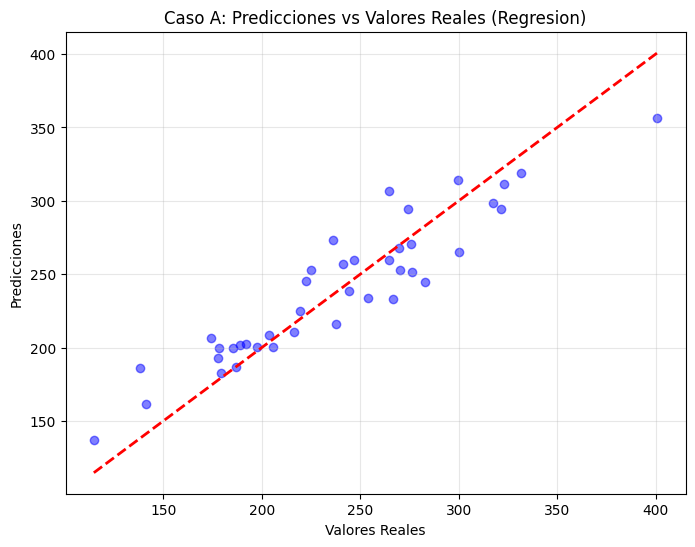


CASO B: Deteccion de abandono de clientes (Clasificacion binaria)
Modelo: Regresion Logistica

Distribucion de la variable objetivo:
Clientes que abandonan (clase 1): 157 (31.4%)
Clientes que no abandonan (clase 0): 343 (68.6%)

Metricas del modelo:
Accuracy: 0.8500
Precision: 0.7368
Recall (Sensibilidad): 0.5833
F1-Score: 0.6512
AUC-ROC: 0.8317

Matriz de Confusion:
              Realidad
            Abandona  No abandona
Predice Abandona     71        5
Predice No abandona  10        14

Interpretacion:
- VP (Verdaderos Positivos): 14
- FP (Falsos Positivos): 5
- FN (Falsos Negativos): 10
- VN (Verdaderos Negativos): 71
- El modelo detecta el 58.3% de los abandonos reales
- Cuando predice abandono, acierta el 73.7% de las veces


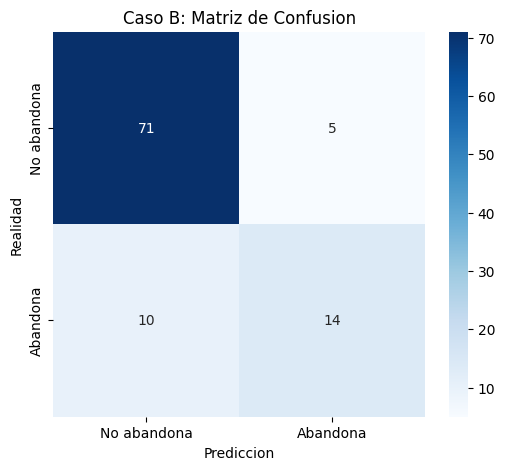

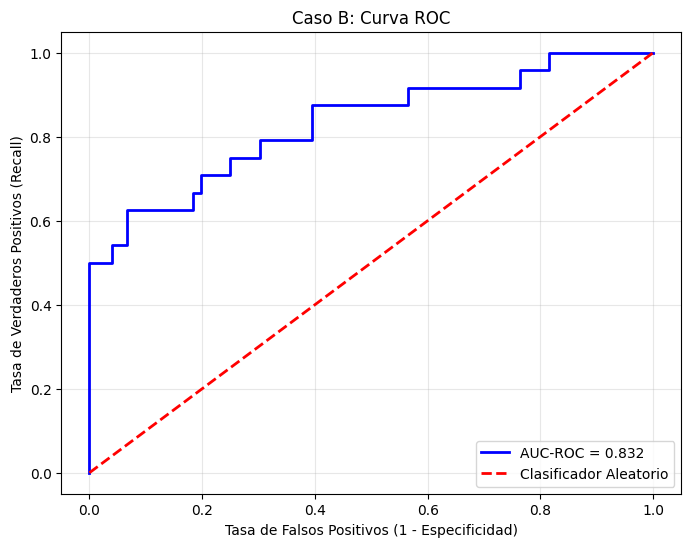


CASO C: Segmentacion de clientes bancarios (Clustering no supervisado)
Modelo: K-Means Clustering


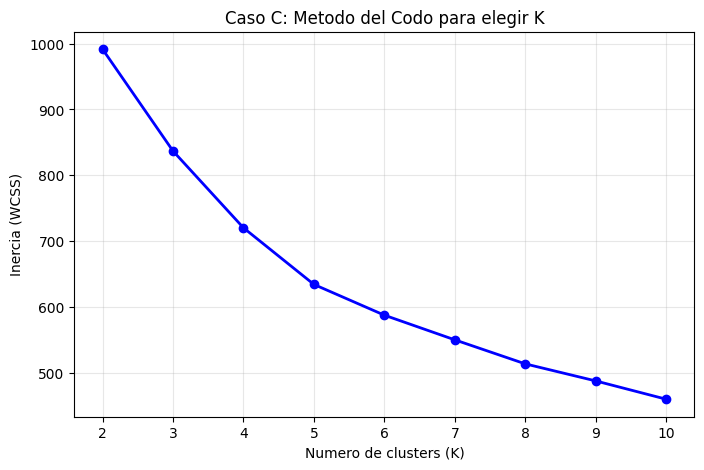


Resultados del clustering con K=3:
Coeficiente de Silueta: 0.1769
Davies-Bouldin Index: 1.6326
Inercia (WCSS): 836.85

Interpretacion:
- Coeficiente de Silueta = 0.177: Los clusters son difusos y se superponen

Distribucion de clientes por cluster:
  Cluster 0: 98 clientes (32.7%)
  Cluster 1: 111 clientes (37.0%)
  Cluster 2: 91 clientes (30.3%)


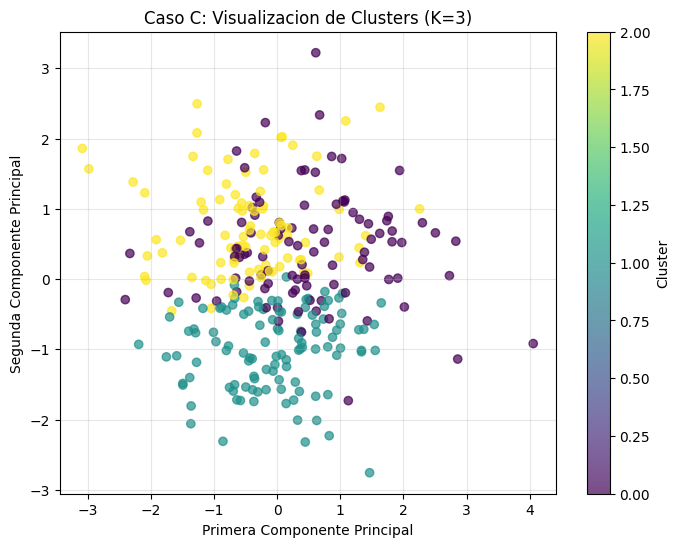


RESUMEN DE METRICAS POR CASO
            Caso                  Modelo  Metrica Principal   Metrica Secundaria 1 Metrica Secundaria 2
    A: Regresion Random Forest Regressor       RMSE = 22.43            MAE = 18.58           R² = 0.855
B: Clasificacion     Regresion Logistica    AUC-ROC = 0.832       F1-Score = 0.651       Recall = 0.583
   C: Clustering                 K-Means Silhouette = 0.177 Davies-Bouldin = 1.633        Inercia = 837

CONCLUSIONES

1. Caso A (Regresion): El modelo Random Forest explica bien la variabilidad de las ventas.
   El MAPE permite comunicar resultados en porcentaje al negocio.

2. Caso B (Clasificacion): La matriz de confusion muestra que el error mas critico
   es el Falso Negativo (no detectar un cliente que abandona). Se prioriza Recall.

3. Caso C (Clustering): El coeficiente de silueta indica que tan bien separados
   estan los clusters. Se debe validar con expertos de negocio.


FIN DEL ANALISIS


In [1]:
# ============================================================
# PROPUESTA DE METRICAS DE EVALUACION PARA CADA MODELO
# Caso: DataSolutions S.A.
# Autor: Analista de datos
# ============================================================

# Instalar dependencias (si es necesario)
# !pip install scikit-learn numpy pandas matplotlib seaborn

# Importar librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    silhouette_score,
    davies_bouldin_score,
    classification_report
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("METRICAS DE EVALUACION PARA LOS TRES CASOS")
print("=" * 60)

# ============================================================
# CASO A: PREDICCION DE VENTAS SEMANALES (REGRESION)
# ============================================================

print("\n" + "=" * 60)
print("CASO A: Prediccion de ventas semanales (Regresion)")
print("Modelo: Random Forest Regressor")
print("=" * 60)

# Generar datos simulados de ventas
np.random.seed(42)
n_samples = 200

# Variables independientes
tamaño_tienda = np.random.normal(100, 30, n_samples)  # metros cuadrados
num_empleados = np.random.poisson(15, n_samples)       # cantidad de empleados
distancia_centro = np.random.uniform(0, 10, n_samples) # km al centro

# Variable dependiente (ventas semanales en miles)
ventas = (2 * tamaño_tienda +
          3 * num_empleados -
          1.5 * distancia_centro +
          np.random.normal(0, 20, n_samples))

X_reg = np.column_stack([tamaño_tienda, num_empleados, distancia_centro])
y_reg = ventas

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Entrenar modelo
modelo_reg = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_reg.fit(X_train, y_train)

# Predicciones
y_pred_reg = modelo_reg.predict(X_test)

# Calcular metricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred_reg))
mae = mean_absolute_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)
mape = np.mean(np.abs((y_test - y_pred_reg) / y_test)) * 100

print("\nResultados del modelo:")
print(f"RMSE (Root Mean Square Error): {rmse:.2f} miles de unidades")
print(f"MAE (Mean Absolute Error): {mae:.2f} miles de unidades")
print(f"R² (Coeficiente de determinacion): {r2:.4f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")

print("\nInterpretacion:")
print(f"- El error tipico es de {rmse:.2f} miles de unidades monetarias")
print(f"- El modelo explica el {r2*100:.1f}% de la variabilidad de las ventas")
print(f"- Las predicciones fallan en promedio un {mape:.1f}%")

# Grafico de predicciones vs reales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_reg, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Caso A: Predicciones vs Valores Reales (Regresion)")
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# CASO B: DETECCION DE ABANDONO DE CLIENTES (CLASIFICACION BINARIA)
# ============================================================

print("\n" + "=" * 60)
print("CASO B: Deteccion de abandono de clientes (Clasificacion binaria)")
print("Modelo: Regresion Logistica")
print("=" * 60)

# Generar datos simulados de clientes
np.random.seed(42)
n_clientes = 500

# Variables de los clientes
dias_sin_uso = np.random.exponential(30, n_clientes)  # dias sin actividad
reclamos = np.random.poisson(2, n_clientes)            # cantidad de reclamos
edad_cliente = np.random.normal(35, 10, n_clientes)    # edad
plan_premium = np.random.binomial(1, 0.4, n_clientes)  # 1 si tiene plan premium

# Variable objetivo: abandono (1 = abandona, 0 = no abandona)
log_odds = -2 + 0.05 * dias_sin_uso + 0.3 * reclamos - 0.02 * edad_cliente - 0.5 * plan_premium
prob_abandono = 1 / (1 + np.exp(-log_odds))
abandono = np.random.binomial(1, prob_abandono)

X_clas = np.column_stack([dias_sin_uso, reclamos, edad_cliente, plan_premium])
y_clas = abandono

print(f"\nDistribucion de la variable objetivo:")
print(f"Clientes que abandonan (clase 1): {sum(y_clas)} ({sum(y_clas)/len(y_clas)*100:.1f}%)")
print(f"Clientes que no abandonan (clase 0): {len(y_clas)-sum(y_clas)} ({(len(y_clas)-sum(y_clas))/len(y_clas)*100:.1f}%)")

# Dividir datos
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clas, y_clas, test_size=0.2, random_state=42)

# Escalar datos
scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

# Entrenar modelo
modelo_clas = LogisticRegression(random_state=42)
modelo_clas.fit(X_train_c_scaled, y_train_c)

# Predicciones
y_pred_c = modelo_clas.predict(X_test_c_scaled)
y_pred_proba = modelo_clas.predict_proba(X_test_c_scaled)[:, 1]

# Calcular metricas
accuracy = accuracy_score(y_test_c, y_pred_c)
precision = precision_score(y_test_c, y_pred_c)
recall = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)
auc_roc = roc_auc_score(y_test_c, y_pred_proba)

print("\nMetricas del modelo:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensibilidad): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

# Matriz de confusion
cm = confusion_matrix(y_test_c, y_pred_c)
print("\nMatriz de Confusion:")
print("              Realidad")
print("            Abandona  No abandona")
print(f"Predice Abandona     {cm[0,0]}        {cm[0,1]}")
print(f"Predice No abandona  {cm[1,0]}        {cm[1,1]}")

print(f"\nInterpretacion:")
print(f"- VP (Verdaderos Positivos): {cm[1,1]}")
print(f"- FP (Falsos Positivos): {cm[0,1]}")
print(f"- FN (Falsos Negativos): {cm[1,0]}")
print(f"- VN (Verdaderos Negativos): {cm[0,0]}")
print(f"- El modelo detecta el {recall*100:.1f}% de los abandonos reales")
print(f"- Cuando predice abandono, acierta el {precision*100:.1f}% de las veces")

# Grafico matriz de confusion
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No abandona', 'Abandona'],
            yticklabels=['No abandona', 'Abandona'])
plt.xlabel('Prediccion')
plt.ylabel('Realidad')
plt.title('Caso B: Matriz de Confusion')
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test_c, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', lw=2, label=f'AUC-ROC = {auc_roc:.3f}')
plt.plot([0, 1], [0, 1], 'r--', lw=2, label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Caso B: Curva ROC')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# CASO C: SEGMENTACION DE CLIENTES BANCARIOS (CLUSTERING)
# ============================================================

print("\n" + "=" * 60)
print("CASO C: Segmentacion de clientes bancarios (Clustering no supervisado)")
print("Modelo: K-Means Clustering")
print("=" * 60)

# Generar datos simulados de clientes bancarios
np.random.seed(42)
n_clientes_bank = 300

# Caracteristicas de clientes
ingreso_mensual = np.random.normal(3000, 1000, n_clientes_bank)      # en dolares
gasto_tarjeta = np.random.normal(800, 300, n_clientes_bank)          # en dolares
num_transacciones = np.random.poisson(20, n_clientes_bank)           # por mes
saldo_promedio = np.random.normal(5000, 2000, n_clientes_bank)       # en dolares

X_clust = np.column_stack([ingreso_mensual, gasto_tarjeta, num_transacciones, saldo_promedio])

# Escalar datos (importante para K-Means)
scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_clust)

# Probar diferentes valores de K para encontrar el optimo (Metodo del codo)
inercia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clust_scaled)
    inercia.append(kmeans.inertia_)

# Grafico metodo del codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inercia, 'bo-', linewidth=2)
plt.xlabel('Numero de clusters (K)')
plt.ylabel('Inercia (WCSS)')
plt.title('Caso C: Metodo del Codo para elegir K')
plt.grid(True, alpha=0.3)
plt.show()

# Elegir K=3 para el ejemplo
k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_clust_scaled)

# Calcular metricas de clustering
silhouette = silhouette_score(X_clust_scaled, labels)
davies_bouldin = davies_bouldin_score(X_clust_scaled, labels)

print(f"\nResultados del clustering con K={k_optimo}:")
print(f"Coeficiente de Silueta: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"Inercia (WCSS): {kmeans.inertia_:.2f}")

print("\nInterpretacion:")
if silhouette >= 0.7:
    print(f"- Coeficiente de Silueta = {silhouette:.3f}: Los clusters estan bien separados y son compactos")
elif silhouette >= 0.5:
    print(f"- Coeficiente de Silueta = {silhouette:.3f}: Los clusters son aceptables")
else:
    print(f"- Coeficiente de Silueta = {silhouette:.3f}: Los clusters son difusos y se superponen")

# Distribucion de clientes por cluster
unique, counts = np.unique(labels, return_counts=True)
print(f"\nDistribucion de clientes por cluster:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} clientes ({count/n_clientes_bank*100:.1f}%)")

# Grafico de clusters (usando las 2 primeras componentes)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clust_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Primera Componente Principal')
plt.ylabel('Segunda Componente Principal')
plt.title(f'Caso C: Visualizacion de Clusters (K={k_optimo})')
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# RESUMEN FINAL DE METRICAS
# ============================================================

print("\n" + "=" * 60)
print("RESUMEN DE METRICAS POR CASO")
print("=" * 60)

resumen = pd.DataFrame({
    'Caso': ['A: Regresion', 'B: Clasificacion', 'C: Clustering'],
    'Modelo': ['Random Forest Regressor', 'Regresion Logistica', 'K-Means'],
    'Metrica Principal': [f'RMSE = {rmse:.2f}', f'AUC-ROC = {auc_roc:.3f}', f'Silhouette = {silhouette:.3f}'],
    'Metrica Secundaria 1': [f'MAE = {mae:.2f}', f'F1-Score = {f1:.3f}', f'Davies-Bouldin = {davies_bouldin:.3f}'],
    'Metrica Secundaria 2': [f'R² = {r2:.3f}', f'Recall = {recall:.3f}', f'Inercia = {kmeans.inertia_:.0f}']
})

print(resumen.to_string(index=False))

print("\n" + "=" * 60)
print("CONCLUSIONES")
print("=" * 60)
print("""
1. Caso A (Regresion): El modelo Random Forest explica bien la variabilidad de las ventas.
   El MAPE permite comunicar resultados en porcentaje al negocio.

2. Caso B (Clasificacion): La matriz de confusion muestra que el error mas critico
   es el Falso Negativo (no detectar un cliente que abandona). Se prioriza Recall.

3. Caso C (Clustering): El coeficiente de silueta indica que tan bien separados
   estan los clusters. Se debe validar con expertos de negocio.
""")

print("\n" + "=" * 60)
print("FIN DEL ANALISIS")
print("=" * 60)